# Can we predict frequency of cannabis usage based on people's demographics, level of education, self-reported impulsivity levels, and gender?

In [29]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 
from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz 

from ucimlrepo import fetch_ucirepo 
  
# Fetching the dataset

drug_consumption = fetch_ucirepo(id=373) 

# Converting the dataset to a pandas dataframe

drugs_df = pd.concat([drug_consumption.data.features, drug_consumption.data.targets], axis=1)

drugs_df.info() # Printing variable types
drugs_df.head() # Printing the first five rows of the dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1885 non-null   float64
 1   gender     1885 non-null   float64
 2   education  1885 non-null   float64
 3   country    1885 non-null   float64
 4   ethnicity  1885 non-null   float64
 5   nscore     1885 non-null   float64
 6   escore     1885 non-null   float64
 7   oscore     1885 non-null   float64
 8   ascore     1885 non-null   float64
 9   cscore     1885 non-null   float64
 10  impuslive  1885 non-null   float64
 11  ss         1885 non-null   float64
 12  alcohol    1885 non-null   object 
 13  amphet     1885 non-null   object 
 14  amyl       1885 non-null   object 
 15  benzos     1885 non-null   object 
 16  caff       1885 non-null   object 
 17  cannabis   1885 non-null   object 
 18  choc       1885 non-null   object 
 19  coke       1885 non-null   object 
 20  crack   

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [30]:
# Only keeping necessary columns to predict cannabis usage

cannabis_df = drugs_df[['age', 'gender', 'education', 'country', 'ethnicity', 'impuslive', 'cannabis', 'nscore', 'escore', 'oscore', 'ascore', 'cscore', 'ss']]

cannabis_df = cannabis_df.dropna() # Dropping any NA values

cannabis_df.head() # Printing the first five rows of the new dataset

,age,gender,education,country,ethnicity,impuslive,cannabis,nscore,escore,oscore,ascore,cscore,ss
0,0.49788,0.48246,-0.05921,0.96082,0.12600,-0.21712,CL0,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-1.18084
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.71126,CL4,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.21575
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-1.37983,CL3,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,0.40148
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-1.37983,CL2,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.18084
4,0.49788,0.48246,1.98437,0.96082,-0.31685,-0.21712,CL3,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21575


In [31]:
cannabis_df[["cannabis"]] = OrdinalEncoder().fit_transform(cannabis_df[["cannabis"]]) # Ordinally encoding our target variable

print(cannabis_df['cannabis'].value_counts()) # Checking the statistics of each cannabis usage frequency category


cannabis
6.0    463
0.0    413
2.0    266
3.0    211
1.0    207
5.0    185
4.0    140
Name: count, dtype: int64


In [32]:
# Splitting the data

X = cannabis_df.drop(columns = 'cannabis') # Defining our feature variables
y = cannabis_df.cannabis # Defining our target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.70, stratify= y, random_state = 42)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state = 30)

In [33]:
# Starting the cross validation process with 10 splits and 5 repeats

kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 5, random_state=42)

In [34]:
# Defining our scoring metrics

scoring = {
    'roc_auc': 'roc_auc_ovr',             
    'recall': 'recall_macro',               
    'balanced_accuracy': 'balanced_accuracy'  
}



In [35]:
# Using max_depth as our hyperparameter

param = {"max_depth" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]}

In [36]:
cl = DecisionTreeClassifier(random_state=1000) # Defining the classifier model

# Searching for the best classifier based on balanced_accuracy

search = GridSearchCV(cl, param, scoring = scoring, n_jobs = -1, cv = kf, refit = 'balanced_accuracy') 

model = search.fit(X_train, y_train) # Fitting the model based on the training data

In [37]:
# Finding the best max_depth

best = model.best_estimator_
print(best)

DecisionTreeClassifier(max_depth=7, random_state=1000)


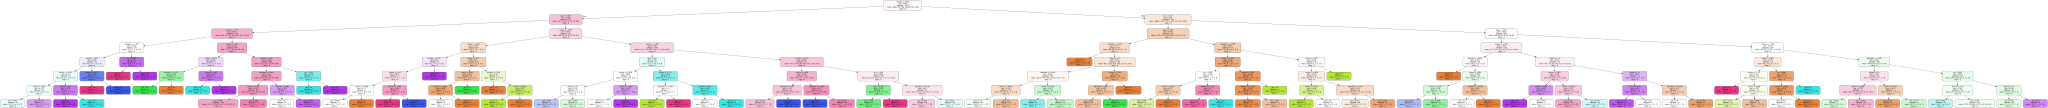

In [38]:
# Printing the decision tree

dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns,
               filled=True, 
                rounded=True, 
                class_names = ['0', '1', '2', '3', '4', '5', '6'])
               
graph=graphviz.Source(dot_data)
graph

In [39]:
print(model.cv_results_)

{'mean_fit_time': array([0.00418976, 0.00429513, 0.00666741, 0.00526004, 0.00563669,
       0.00615866, 0.00705415, 0.00750963, 0.00887499, 0.01049395,
       0.01015689, 0.01261859, 0.01093115, 0.01034544, 0.0101108 ]), 'std_fit_time': array([0.00161042, 0.00170341, 0.00380175, 0.00145958, 0.00064696,
       0.0003881 , 0.0014407 , 0.00069065, 0.0024144 , 0.0034617 ,
       0.00292364, 0.00581371, 0.00399599, 0.00082629, 0.00099567]), 'mean_score_time': array([0.0150585 , 0.01564872, 0.02015439, 0.01497028, 0.01379584,
       0.01422961, 0.01454172, 0.01342104, 0.01501131, 0.01517404,
       0.01549403, 0.01722027, 0.01437177, 0.01337415, 0.01333045]), 'std_score_time': array([0.00424079, 0.00536549, 0.00812239, 0.00298798, 0.00104664,
       0.00242132, 0.00214104, 0.00102316, 0.00613717, 0.00440062,
       0.00475376, 0.0071953 , 0.0037321 , 0.00225595, 0.00167363]), 'param_max_depth': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
             mask=[False, F

In [40]:
auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']

depth= np.unique(model.cv_results_['param_max_depth'])

final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

final_model

,depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
0,1,0.649406,0.234227,0.234227,0.020692,0.013902,0.013902
1,2,0.688554,0.233569,0.233569,0.024163,0.015618,0.015618
2,3,0.714004,0.244764,0.244764,0.023739,0.019920,0.019920
3,4,0.705771,0.256282,0.256282,0.023770,0.025199,0.025199
4,5,0.699758,0.253424,0.253424,0.028602,0.026987,0.026987
5,6,0.683880,0.269349,0.269349,0.030033,0.030653,0.030653
6,7,0.659327,0.272145,0.272145,0.031053,0.036101,0.036101
7,8,0.644657,0.267062,0.267062,0.028716,0.031170,0.031170
8,9,0.624423,0.262877,0.262877,0.024904,0.033096,0.033096
9,10,0.609189,0.262983,0.262983,0.024467,0.030691,0.030691


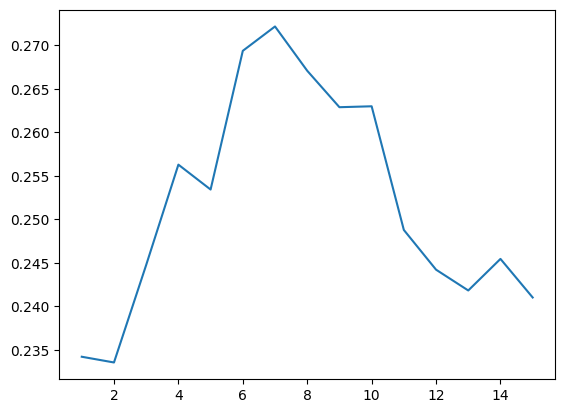

In [41]:
# Finding what depth has the highest balanced accuracy

print(plt.plot(final_model.depth,final_model.bal_acc))

In [42]:
varimp = pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

           importance
country      0.252241
ss           0.102855
cscore       0.098088
escore       0.089411
age          0.085987
oscore       0.085383
ascore       0.071183
education    0.063376
nscore       0.050125
impuslive    0.049298
ethnicity    0.029822
gender       0.022231
